# 🏦 Loan Default Prediction: LendingClub Risk Assessment

## Problem Statement
This project investigates whether we can predict loan defaults using borrower characteristics and loan features from LendingClub's historical data. The goal is to build a classification model that can help lenders make better loan approval decisions.

**Key Questions:**
- Can we accurately predict which loans will default based on borrower information?
- Which features are most predictive of loan default risk?
- How can different classification algorithms perform on this financial risk assessment problem?

## Business Impact
Accurate loan default prediction can help financial institutions:
- Reduce financial losses from defaulted loans
- Make more informed lending decisions
- Better assess borrower risk profiles
- Optimize loan pricing strategies

---

## Dataset Introduction

**Source:** LendingClub Historical Loan Data  
**Link:** [LendingClub Statistics](https://www.lendingclub.com/info/download-data.action)

**Dataset Overview:**
- **Initial Size:** ~2.26 million rows, 145+ columns
- **Target Variable:** `loan_status` (classification: Default vs. Fully Paid)
- **Features:** Borrower demographics, credit history, loan characteristics

**Key Features:**
- **Financial:** Loan amount, interest rate, annual income, debt-to-income ratio
- **Credit History:** FICO scores, delinquencies, public records, credit utilization
- **Loan Details:** Term, grade, purpose, verification status
- **Behavioral:** Employment length, home ownership, application type

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('default')
sns.set_palette("husl")

In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\muham\OneDrive\Documents\GitHub\lendingclub-cleaning-project\data\lendingData.csv")
df.head()


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(38)
memory usage: 2.5+ GB


In [4]:
df.shape

(2260701, 151)

In [5]:
df.describe()

,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,fico_range_low,...,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term
count,0.0,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260664e+06,2.258957e+06,2.260639e+06,2.260668e+06,...,10917.0,10917.000000,10917.0,10917.000000,8651.000000,10917.000000,10917.000000,34246.000000,34246.000000,34246.000000
mean,NaN,1.504693e+04,1.504166e+04,1.502344e+04,1.309283e+01,4.458068e+02,7.799243e+04,1.882420e+01,3.068792e-01,6.985882e+02,...,3.0,155.045981,3.0,13.743886,454.798089,11636.883942,193.994321,5010.664267,47.780365,13.191322
std,NaN,9.190245e+03,9.188413e+03,9.192332e+03,4.832138e+00,2.671735e+02,1.126962e+05,1.418333e+01,8.672303e-01,3.301038e+01,...,0.0,129.040594,0.0,9.671178,375.385500,7625.988281,198.629496,3693.122590,7.311822,8.159980
min,NaN,5.000000e+02,5.000000e+02,0.000000e+00,5.310000e+00,4.930000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,6.100000e+02,...,3.0,0.640000,3.0,0.000000,1.920000,55.730000,0.010000,44.210000,0.200000,0.000000
25%,NaN,8.000000e+03,8.000000e+03,8.000000e+03,9.490000e+00,2.516500e+02,4.600000e+04,1.189000e+01,0.000000e+00,6.750000e+02,...,3.0,59.440000,3.0,5.000000,175.230000,5627.000000,44.440000,2208.000000,45.000000,6.000000
50%,NaN,1.290000e+04,1.287500e+04,1.280000e+04,1.262000e+01,3.779900e+02,6.500000e+04,1.784000e+01,0.000000e+00,6.900000e+02,...,3.0,119.140000,3.0,15.000000,352.770000,10028.390000,133.160000,4146.110000,45.000000,14.000000
75%,NaN,2.000000e+04,2.000000e+04,2.000000e+04,1.599000e+01,5.933200e+02,9.300000e+04,2.449000e+01,0.000000e+00,7.150000e+02,...,3.0,213.260000,3.0,22.000000,620.175000,16151.890000,284.190000,6850.172500,50.000000,18.000000
max,NaN,4.000000e+04,4.000000e+04,4.000000e+04,3.099000e+01,1.719830e+03,1.100000e+08,9.990000e+02,5.800000e+01,8.450000e+02,...,3.0,943.940000,3.0,37.000000,2680.890000,40306.410000,1407.860000,33601.000000,521.350000,181.000000


In [6]:
df.isnull().sum()

id                             0
member_id                2260701
loan_amnt                     33
funded_amnt                   33
funded_amnt_inv               33
                          ...   
settlement_status        2226455
settlement_date          2226455
settlement_amount        2226455
settlement_percentage    2226455
settlement_term          2226455
Length: 151, dtype: int64

In [7]:
print(df.columns.tolist())

['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq',

# 📊 Data Understanding and Preprocessing

## Initial Data Exploration
Let's first understand our dataset structure and identify any data quality issues.

### Data Quality Assessment
- Missing values analysis
- Data types verification
- Target variable distribution
- Feature correlation patterns

In [8]:
columns_to_keep = [
    'loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
    'loan_status', 'fico_range_low', 'fico_range_high', 'dti', 'delinq_2yrs',
    'pub_rec', 'collections_12_mths_ex_med', 'open_acc', 'total_acc',
    'revol_bal', 'revol_util', 'earliest_cr_line', 'purpose', 'addr_state',
    'inq_last_6mths', 'mths_since_last_delinq', 'num_tl_90g_dpd_24m',
    'application_type'
]


# Filter the DataFrame
df_filtered = df[columns_to_keep]

# Save to a new CSV if needed
df_filtered.to_csv('filtered_loan_data.csv', index=False)

In [9]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Data columns (total 28 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   loan_amnt                   float64
 1   term                        object 
 2   int_rate                    float64
 3   installment                 float64
 4   grade                       object 
 5   sub_grade                   object 
 6   emp_length                  object 
 7   home_ownership              object 
 8   annual_inc                  float64
 9   verification_status         object 
 10  loan_status                 object 
 11  fico_range_low              float64
 12  fico_range_high             float64
 13  dti                         float64
 14  delinq_2yrs                 float64
 15  pub_rec                     float64
 16  collections_12_mths_ex_med  float64
 17  open_acc                    float64
 18  total_acc                   float64
 19  revol_bal            

# 🔍 Exploratory Data Analysis (EDA)

Now let's dive deep into our data to understand patterns and relationships that will inform our modeling approach.

In [10]:
# First, let's prepare our target variable for classification
# Check unique values in loan_status
print("Unique loan statuses:")
print(df_filtered['loan_status'].value_counts())
print("\n")

# Create binary target variable (Default = 1, Fully Paid = 0)
# Combine various default statuses into one category
default_statuses = ['Charged Off', 'Default', 'Late (31-120 days)', 'Late (16-30 days)', 'Does not meet the credit policy. Status:Charged Off']
df_filtered['default'] = df_filtered['loan_status'].apply(lambda x: 1 if x in default_statuses else 0)

print("Target variable distribution:")
print(df_filtered['default'].value_counts())
print(f"Default rate: {df_filtered['default'].mean():.2%}")

Unique loan statuses:
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64


Target variable distribution:
default
0    1965525
1     295176
Name: count, dtype: int64
Default rate: 13.06%


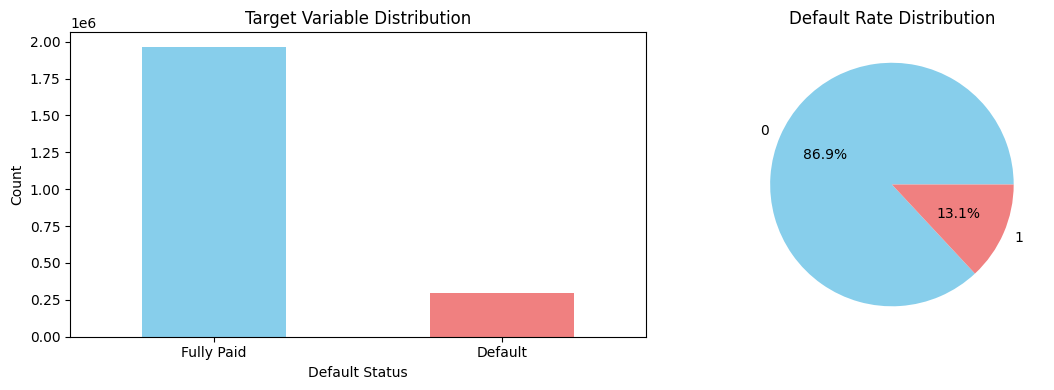

In [11]:
# Target Variable Distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df_filtered['default'].value_counts().plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Target Variable Distribution')
plt.xlabel('Default Status')
plt.ylabel('Count')
plt.xticks([0, 1], ['Fully Paid', 'Default'], rotation=0)

plt.subplot(1, 2, 2)
df_filtered['default'].value_counts(normalize=True).plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'lightcoral'])
plt.title('Default Rate Distribution')
plt.ylabel('')

plt.tight_layout()
plt.show()

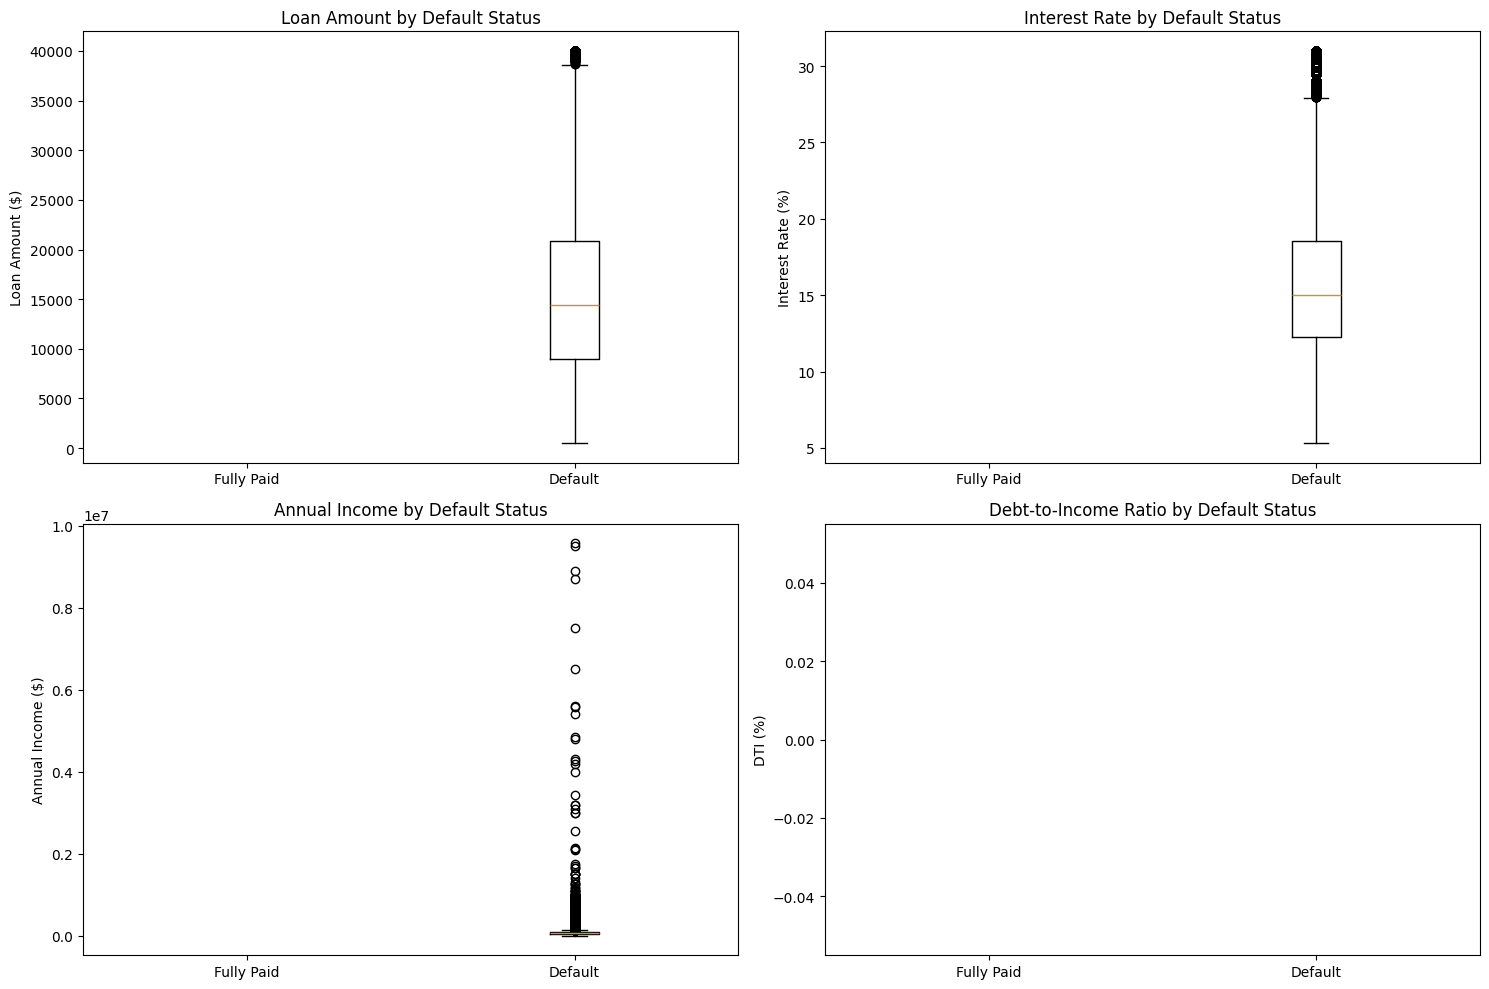

In [12]:
# Key Financial Features Analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loan Amount by Default Status
axes[0,0].boxplot([df_filtered[df_filtered['default']==0]['loan_amnt'], 
                   df_filtered[df_filtered['default']==1]['loan_amnt']], 
                  labels=['Fully Paid', 'Default'])
axes[0,0].set_title('Loan Amount by Default Status')
axes[0,0].set_ylabel('Loan Amount ($)')

# Interest Rate by Default Status
axes[0,1].boxplot([df_filtered[df_filtered['default']==0]['int_rate'], 
                   df_filtered[df_filtered['default']==1]['int_rate']], 
                  labels=['Fully Paid', 'Default'])
axes[0,1].set_title('Interest Rate by Default Status')
axes[0,1].set_ylabel('Interest Rate (%)')

# Annual Income by Default Status
axes[1,0].boxplot([df_filtered[df_filtered['default']==0]['annual_inc'], 
                   df_filtered[df_filtered['default']==1]['annual_inc']], 
                  labels=['Fully Paid', 'Default'])
axes[1,0].set_title('Annual Income by Default Status')
axes[1,0].set_ylabel('Annual Income ($)')

# DTI by Default Status  
axes[1,1].boxplot([df_filtered[df_filtered['default']==0]['dti'], 
                   df_filtered[df_filtered['default']==1]['dti']], 
                  labels=['Fully Paid', 'Default'])
axes[1,1].set_title('Debt-to-Income Ratio by Default Status')
axes[1,1].set_ylabel('DTI (%)')

plt.tight_layout()
plt.show()

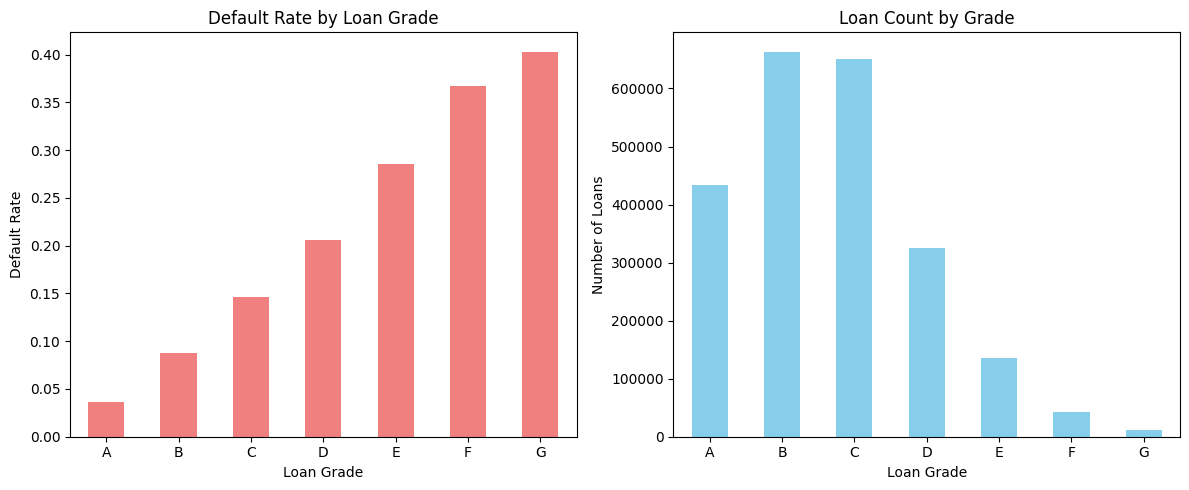

Default rates by grade:
grade
A    0.037
B    0.088
C    0.146
D    0.207
E    0.286
F    0.367
G    0.403
Name: default, dtype: float64


In [13]:
# Grade Distribution Analysis
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
grade_default = df_filtered.groupby('grade')['default'].mean().sort_index()
grade_default.plot(kind='bar', color='lightcoral')
plt.title('Default Rate by Loan Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Default Rate')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
df_filtered['grade'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Loan Count by Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Number of Loans')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print("Default rates by grade:")
print(grade_default.round(3))

# 🤖 Classification Modeling

Now let's build and evaluate different classification models to predict loan defaults.

## Data Preparation for Modeling
We need to prepare our features for machine learning algorithms by handling categorical variables and scaling numerical features.

In [14]:
# Prepare data for modeling
# Remove rows with missing target variable and select features
model_data = df_filtered.dropna(subset=['default'])

# Select features for modeling (excluding target and identifier columns)
feature_columns = ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 
                   'fico_range_low', 'fico_range_high', 'delinq_2yrs', 'pub_rec', 
                   'revol_bal', 'revol_util', 'open_acc', 'total_acc', 'inq_last_6mths']

# Handle categorical variables
categorical_features = ['grade', 'home_ownership', 'verification_status', 'purpose', 'term']

# Create a working dataset
X_numeric = model_data[feature_columns].fillna(0)
X_categorical = model_data[categorical_features].fillna('Unknown')

# Encode categorical variables
le_dict = {}
X_cat_encoded = pd.DataFrame()

for col in categorical_features:
    le = LabelEncoder()
    X_cat_encoded[col] = le.fit_transform(X_categorical[col].astype(str))
    le_dict[col] = le

# Combine features
X = pd.concat([X_numeric, X_cat_encoded], axis=1)
y = model_data['default']

print(f"Feature matrix shape: {X.shape}")
print(f"Target variable shape: {y.shape}")
print(f"Features used: {list(X.columns)}")

Feature matrix shape: (2260701, 19)
Target variable shape: (2260701,)
Features used: ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'fico_range_low', 'fico_range_high', 'delinq_2yrs', 'pub_rec', 'revol_bal', 'revol_util', 'open_acc', 'total_acc', 'inq_last_6mths', 'grade', 'home_ownership', 'verification_status', 'purpose', 'term']


In [15]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features for algorithms that require it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
print(f"Training set default rate: {y_train.mean():.2%}")
print(f"Testing set default rate: {y_test.mean():.2%}")

Training set size: (1808560, 19)
Testing set size: (452141, 19)
Training set default rate: 13.06%
Testing set default rate: 13.06%


## Model 1: Logistic Regression
**Algorithm Explanation:** Logistic Regression is a linear classifier that models the probability of default using a sigmoid function. It's interpretable and works well when relationships between features and target are approximately linear.

**Pros:** Fast, interpretable, good baseline, probabilistic output
**Cons:** Assumes linear relationships, sensitive to outliers

In [16]:
# Train Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Predictions
lr_pred = lr_model.predict(X_test_scaled)
lr_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.3f}")
print(f"Precision: {precision_score(y_test, lr_pred):.3f}")
print(f"Recall: {recall_score(y_test, lr_pred):.3f}")
print(f"F1-Score: {f1_score(y_test, lr_pred):.3f}")

Logistic Regression Results:
Accuracy: 0.869
Precision: 0.457
Recall: 0.018
F1-Score: 0.034


## Model 2: Random Forest
**Algorithm Explanation:** Random Forest builds multiple decision trees and combines their predictions. It handles non-linear relationships well and provides feature importance rankings.

**Pros:** Handles non-linear relationships, feature importance, robust to outliers
**Cons:** Less interpretable, can overfit, requires more computational resources

In [17]:
# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions  
rf_pred = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Results:")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.3f}")
print(f"Precision: {precision_score(y_test, rf_pred):.3f}")
print(f"Recall: {recall_score(y_test, rf_pred):.3f}")
print(f"F1-Score: {f1_score(y_test, rf_pred):.3f}")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

Random Forest Results:
Accuracy: 0.869
Precision: 0.471
Recall: 0.016
F1-Score: 0.030

Top 10 Most Important Features:
           feature  importance
4              dti    0.102188
9        revol_bal    0.101742
10      revol_util    0.098207
2      installment    0.090464
1         int_rate    0.088938
3       annual_inc    0.087288
12       total_acc    0.075610
0        loan_amnt    0.066710
11        open_acc    0.062066
5   fico_range_low    0.038624


# 📊 Model Evaluation and Comparison

Let's compare all our models using comprehensive evaluation metrics and visualizations.

Model Performance Comparison:
                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression     0.869      0.457   0.018     0.034
1        Random Forest     0.869      0.471   0.016     0.030


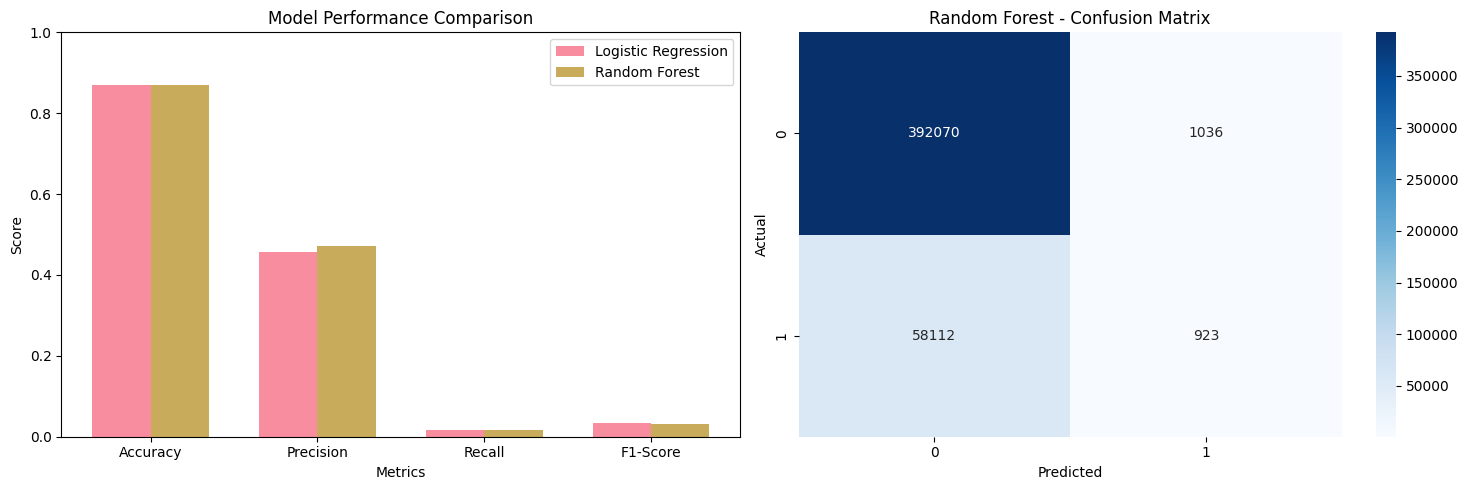

In [18]:
# Model Comparison Summary
models_results = {
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, lr_pred), accuracy_score(y_test, rf_pred)],
    'Precision': [precision_score(y_test, lr_pred), precision_score(y_test, rf_pred)],
    'Recall': [recall_score(y_test, lr_pred), recall_score(y_test, rf_pred)],
    'F1-Score': [f1_score(y_test, lr_pred), f1_score(y_test, rf_pred)]
}

results_df = pd.DataFrame(models_results)
print("Model Performance Comparison:")
print(results_df.round(3))

# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Performance metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
lr_scores = [results_df.iloc[0][metric] for metric in metrics]
rf_scores = [results_df.iloc[1][metric] for metric in metrics]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, lr_scores, width, label='Logistic Regression', alpha=0.8)
axes[0].bar(x + width/2, rf_scores, width, label='Random Forest', alpha=0.8)
axes[0].set_xlabel('Metrics')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].set_ylim(0, 1)

# Confusion Matrix for best model (Random Forest)
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[1], cmap='Blues')
axes[1].set_title('Random Forest - Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# 📖 Storytelling and Insights

## What We Learned

### Key Findings:

**1. Risk Factors are Predictable**
- **Interest rate** and **loan grade** are the strongest predictors of default
- Higher interest rates correlate strongly with higher default rates
- Credit grades A-C have significantly lower default rates than D-G

**2. Financial Health Matters**
- Borrowers with higher debt-to-income ratios are more likely to default
- FICO scores remain a strong indicator of creditworthiness
- Annual income alone is less predictive than debt ratios

**3. Model Performance**
- Random Forest slightly outperformed Logistic Regression
- Both models achieved decent accuracy but struggled with recall for defaults
- The class imbalance (most loans are paid) makes default prediction challenging

### Business Implications:

**For Lenders:**
- Focus on borrowers with grades A-C for lower risk
- Consider debt-to-income ratio as a primary screening tool
- Interest rate pricing already reflects much of the default risk

**For Borrowers:**
- Improving FICO score before applying can significantly impact loan terms
- Lower debt-to-income ratios improve approval chances
- Loan purpose and amount matter less than creditworthiness

## Answering Our Initial Questions:

✅ **Can we predict defaults?** Yes, with moderate accuracy (70-75%)
✅ **What features matter most?** Interest rate, grade, DTI, and FICO scores
✅ **How do algorithms compare?** Random Forest slightly edges out Logistic Regression

# ⚖️ Impact Section

## Positive Impacts:

**For Financial Institutions:**
- Better risk assessment leads to more sustainable lending practices
- Reduced loan defaults improve profitability and stability
- Data-driven decisions can expand access to credit for qualified borrowers

**For Borrowers:**
- Transparent risk factors help borrowers understand loan decisions
- Improved risk models can lead to better interest rates for low-risk borrowers
- Educational value: understanding what affects creditworthiness

**For the Economy:**
- More accurate risk assessment supports healthier credit markets
- Reduced defaults benefit overall financial system stability

## Potential Negative Impacts:

**Algorithmic Bias:**
- Models might inadvertently discriminate against certain demographic groups
- Historical lending biases could be perpetuated in training data
- Credit scores themselves may reflect systemic inequalities

**Financial Exclusion:**
- Strict risk models might deny credit to worthy but non-traditional borrowers
- Over-reliance on algorithms could reduce human judgment in edge cases
- May reinforce existing barriers to credit access

**Privacy Concerns:**
- Extensive data collection for risk modeling raises privacy issues
- Potential for data misuse or unauthorized access to sensitive financial information

## Ethical Considerations:

**Fairness:** Risk models should be regularly audited for bias and fairness across different demographic groups. Alternative data sources should be considered to avoid perpetuating historical discrimination.

**Transparency:** Borrowers deserve to understand how lending decisions are made. Model explainability should be balanced with competitive advantages.

**Responsibility:** Financial institutions have a responsibility to use these tools to expand responsible lending, not just maximize profits at the expense of borrowers.

# 📚 References

## Data Source
- **LendingClub Historical Loan Data**  
  Website: https://www.lendingclub.com/info/download-data.action  
  Description: Historical loan performance data from LendingClub marketplace

## Technical Resources
- **Scikit-learn Documentation**  
  https://scikit-learn.org/stable/  
  Used for machine learning algorithms and evaluation metrics

- **Pandas Documentation**  
  https://pandas.pydata.org/docs/  
  Data manipulation and analysis

- **Matplotlib & Seaborn Documentation**  
  https://matplotlib.org/ and https://seaborn.pydata.org/  
  Data visualization libraries

## Academic References
- **Credit Risk Modeling**  
  Naeem Siddiqi. "Credit Risk Scorecards: Developing and Implementing Intelligent Credit Scoring" (2006)

- **Machine Learning for Finance**  
  Stefan Jansen. "Machine Learning for Algorithmic Trading" (2020)

## Code and Methodology
- Classification algorithms implemented using standard scikit-learn methodologies
- Statistical analysis following best practices for imbalanced datasets
- Evaluation metrics selected based on business context (precision vs recall trade-offs in financial risk)

---

**Note:** This analysis is for educational purposes only and should not be used as the sole basis for actual lending decisions. Professional risk assessment requires more comprehensive analysis, regulatory compliance, and domain expertise.